# Module 4 Lab 3: Problem 3.2 – Truck list price vs. best price

**Name:** [Roey Kadur]
**Repo URL:** [https://github.com/roee0910/cs82a-portfolio.git]

**Goal:** Find how strongly the list price of a truck is related to its best (sale) price, show it in a scatter plot, and use the pattern to predict one best price.

**Data:** `truck.csv`. Column `X` is the list price and column `Y` is the best (sale) price. Both are in thousands of dollars.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("truck.csv")
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (23, 2)


,X,Y
0,12.4,11.2
1,14.3,12.5
2,14.5,12.7
3,14.9,13.1
4,16.1,14.1


## 1. Check the data
Before calculating anything, I check for missing values and look at the basic statistics.

In [2]:
print("Missing values per column:")
print(df.isna().sum())
df.describe().round(2)

Missing values per column:
X    0
Y    0
dtype: int64


,X,Y
count,23.00,23.00
mean,17.47,15.30
std,2.41,2.06
min,12.40,11.20
25%,15.80,14.05
50%,17.30,15.10
75%,19.30,16.85
max,22.40,19.60


## 2. Pearson correlation
I calculate r three ways to make sure the result is right: with pandas, with NumPy, and with the formula written out by hand.

In [3]:
x = df["X"]   # list price, thousands of dollars
y = df["Y"]   # best (sale) price, thousands of dollars

# Method 1: pandas
r_pandas = x.corr(y)

# Method 2: NumPy
r_numpy = np.corrcoef(x, y)[0, 1]

# Method 3: the formula by hand
r_manual = ((x - x.mean()) * (y - y.mean())).sum() / np.sqrt(((x - x.mean())**2).sum() * ((y - y.mean())**2).sum())

print(f"pandas : {r_pandas:.4f}")
print(f"numpy  : {r_numpy:.4f}")
print(f"manual : {r_manual:.4f}")

r = r_numpy

pandas : 0.9985
numpy  : 0.9985
manual : 0.9985


All three methods give **r = 0.9985**. This is very close to 1, so there is strong positive straight-line relationship: trucks with a higher list price almost always have a higher best price, and the points follow a straight line closely.

## 3. Scatter plot

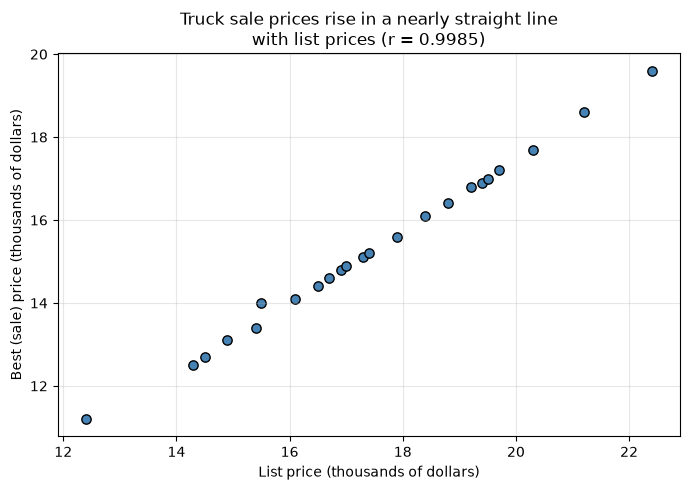

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color="steelblue", edgecolor="black", s=45)
ax.set_title(f"Truck sale prices rise in a nearly straight line\nwith list prices (r = {r:.4f})", fontsize=12)
ax.set_xlabel("List price (thousands of dollars)")
ax.set_ylabel("Best (sale) price (thousands of dollars)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The plot agrees with r: the points sit almost exactly on an upward straight line, with very little spread around it.

## 4. Prediction
Because the relationship is so close to a straight line, I use a straight line to predict. I fit it with `np.polyfit`. I chose a list price of 18 thousand dollars.

In [5]:
slope, intercept = np.polyfit(x, y, 1)

list_price = 18.0   # my chosen list price, in thousands of dollars
predicted_best = slope * list_price + intercept

print(f"Line: best price = {slope:.3f} * list price + {intercept:.3f}")
print(f"Chosen list price: {list_price:.1f} thousand dollars")
print(f"Predicted best price: {predicted_best:.2f} thousand dollars (about ${predicted_best * 1000:,.0f})")

# How far off was the line on the trucks we already have?
residuals = y - (slope * x + intercept)
typical_miss = residuals.std(ddof=2)
largest_miss = residuals.abs().max()
print(f"Typical miss: {typical_miss:.2f} thousand dollars (about ${typical_miss * 1000:,.0f})")
print(f"Largest miss: {largest_miss:.2f} thousand dollars (about ${largest_miss * 1000:,.0f})")

# Is my chosen list price inside the range of the data?
print(f"List prices in the data go from {x.min():.1f} to {x.max():.1f} thousand dollars")
print(f"Is {list_price:.1f} inside that range? {x.min() <= list_price <= x.max()}")

Line: best price = 0.851 * list price + 0.435
Chosen list price: 18.0 thousand dollars
Predicted best price: 15.76 thousand dollars (about $15,755)
Typical miss: 0.11 thousand dollars (about $114)
Largest miss: 0.37 thousand dollars (about $373)
List prices in the data go from 12.4 to 22.4 thousand dollars
Is 18.0 inside that range? True


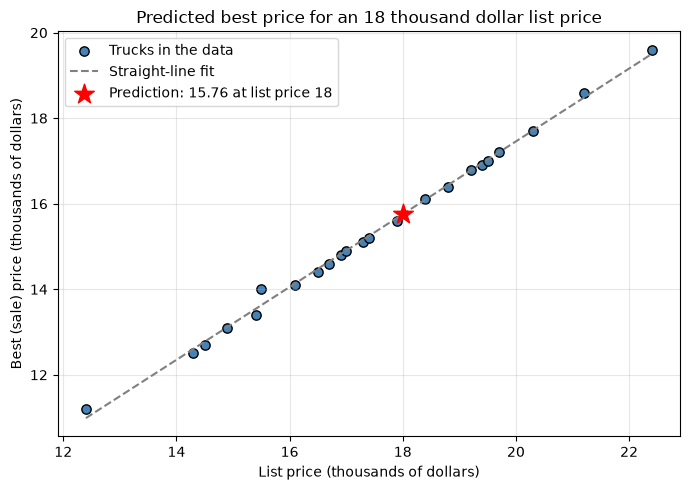

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
line_x = np.linspace(x.min(), x.max(), 100)
ax.scatter(x, y, color="steelblue", edgecolor="black", s=45, label="Trucks in the data")
ax.plot(line_x, slope * line_x + intercept, color="gray", linestyle="--", label="Straight-line fit")
ax.scatter([list_price], [predicted_best], color="red", marker="*", s=220, zorder=5,
           label=f"Prediction: {predicted_best:.2f} at list price {list_price:.0f}")
ax.set_title("Predicted best price for an 18 thousand dollar list price", fontsize=12)
ax.set_xlabel("List price (thousands of dollars)")
ax.set_ylabel("Best (sale) price (thousands of dollars)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Summary of results

In [7]:
summary = pd.DataFrame({
    "Result": ["Pearson r", "Chosen list price (thousands of dollars)",
               "Predicted best price (thousands of dollars)", "Typical miss (thousands of dollars)",
               "Largest miss (thousands of dollars)"],
    "Value": [f"{r:.4f}", f"{list_price:.1f}", f"{predicted_best:.2f}", f"{typical_miss:.2f}", f"{largest_miss:.2f}"]
})
summary

,Result,Value
0,Pearson r,0.9985
1,Chosen list price (thousands of dollars),18.0
2,Predicted best price (thousands of dollars),15.76
3,Typical miss (thousands of dollars),0.11
4,Largest miss (thousands of dollars),0.37


## 6. How confident am I in the prediction?

I am confident in the prediction of about 15.76 thousand dollars, because r is 0.9985 and the line's typical miss on these 23 trucks is only about 0.11 thousand dollars (roughly 114 dollars), with the largest miss around 0.37 thousand dollars (roughly 373 dollars). This only applies to list prices inside the range of the data (12.4 to 22.4 thousand dollars): 18 is inside that range, but I would not trust the line for a truck priced far outside it, because the data does not show how the relationship behaves there. Also, the misses were measured on the same 23 trucks used to draw the line, and the sample is small, so a new truck could miss by somewhat more.